# 05 SQL Analysis

## Objective

This notebook demonstrates how SQL can be used alongside Python to answer key business questions from the IBM Telco Customer Churn dataset.

The SQL queries are executed against a SQLite database and the results are visualized using Matplotlib and Seaborn.

### Business Questions

1. What is the overall churn rate?
2. Which contract type has the highest churn?
3. Which internet service has the highest churn?
4. Which payment method has the highest churn?
5. How much monthly revenue is lost due to churn?
6. Who are the highest-risk customers that should be targeted by retention campaigns?


Overall Churn Rate


,Churn,Customer_Count,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


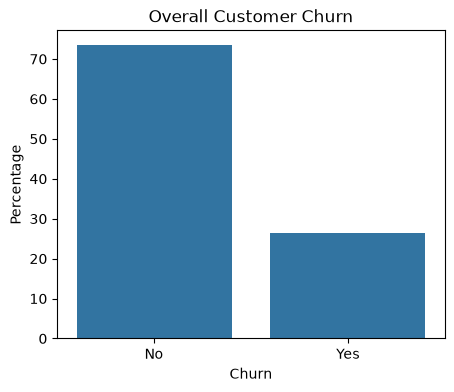


Churn by Contract Type


,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


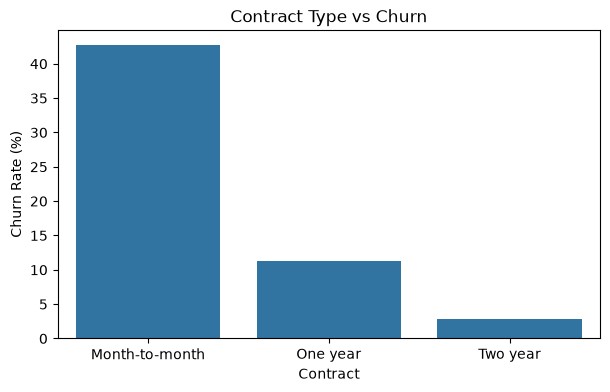


Churn by Internet Service


,InternetService,Customers,Churned,Churn_Rate
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


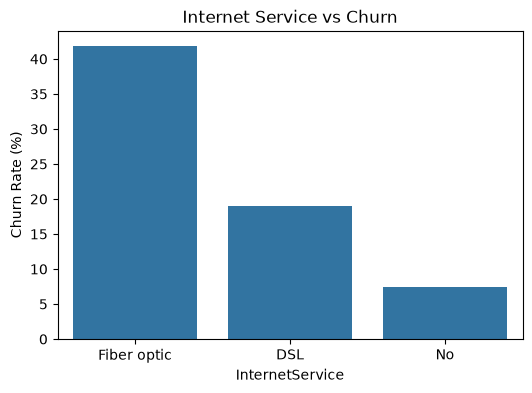


Churn by Payment Method


,PaymentMethod,Customers,Churned,Churn_Rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


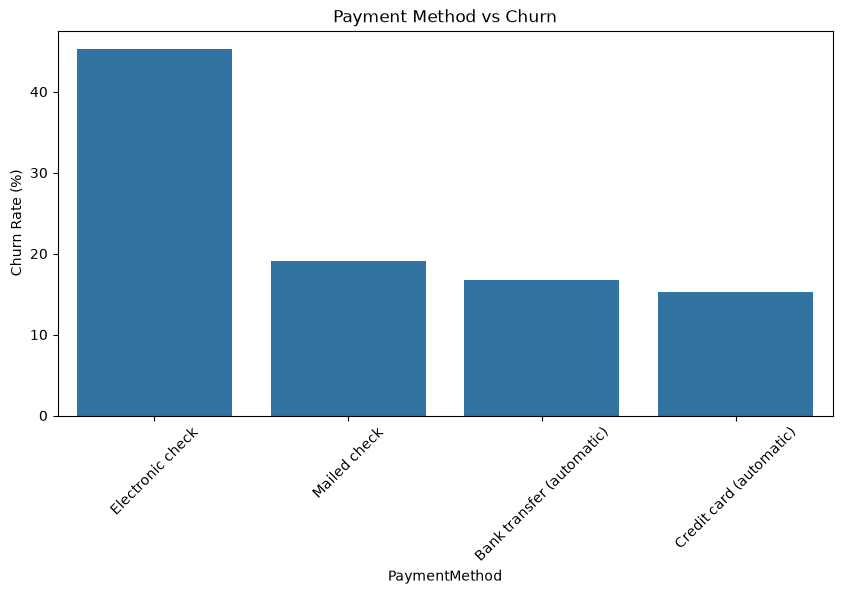


Revenue Lost Due to Churn


,Monthly_Revenue_Lost,Total_Monthly_Revenue,Revenue_Loss_Percentage
0,139130.85,456116.6,30.5



High Risk Customers


,customerID,Contract,tenure,MonthlyCharges,TotalCharges,InternetService,PaymentMethod,TechSupport,OnlineSecurity
0,0771-WLCLA,Month-to-month,16,112.95,1882.55,Fiber optic,Electronic check,Yes,Yes
1,3292-PBZEJ,Month-to-month,11,111.40,1183.05,Fiber optic,Electronic check,Yes,No
2,5760-IFJOZ,Month-to-month,3,107.95,313.60,Fiber optic,Mailed check,No,No
3,2081-VEYEH,Month-to-month,3,107.95,318.60,Fiber optic,Electronic check,Yes,No
4,6591-QGOYB,Month-to-month,17,106.65,1672.10,Fiber optic,Bank transfer (automatic),Yes,Yes
...,...,...,...,...,...,...,...,...,...
378,5119-NZPTV,Month-to-month,2,70.10,141.65,Fiber optic,Electronic check,No,No
379,1304-BCCFO,Month-to-month,9,70.05,564.40,DSL,Mailed check,No,No
380,6705-LXORM,Month-to-month,5,70.05,302.60,Fiber optic,Electronic check,No,No
381,9603-OAIHC,Month-to-month,1,70.05,70.05,Fiber optic,Electronic check,No,No



Total High Risk Customers: 383

SQL Analysis Completed Successfully


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------
# Connect to SQLite Database
# ---------------------------------------

conn = sqlite3.connect("../customer_churn.db")

# ---------------------------------------
# Helper Function
# ---------------------------------------

def run_query(query, title=None):
    df = pd.read_sql_query(query, conn)

    if title:
        print("\n" + "="*80)
        print(title)
        print("="*80)

    display(df)

    return df

# =============================================================================
# 1. Overall Churn Rate
# =============================================================================

query = """
SELECT
    Churn,
    COUNT(*) AS Customer_Count,
    ROUND(COUNT(*)*100.0/
    SUM(COUNT(*)) OVER(),2) AS Percentage
FROM telco_churn
GROUP BY Churn;
"""

overall_churn = run_query(query, "Overall Churn Rate")

plt.figure(figsize=(5,4))
sns.barplot(data=overall_churn,
            x="Churn",
            y="Percentage")

plt.title("Overall Customer Churn")
plt.ylabel("Percentage")
plt.show()


# =============================================================================
# 2. Churn by Contract Type
# =============================================================================

query = """
SELECT
    Contract,
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned_Customers,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/
        COUNT(*),2
    ) AS Churn_Rate
FROM telco_churn
GROUP BY Contract
ORDER BY Churn_Rate DESC;
"""

contract = run_query(query, "Churn by Contract Type")

plt.figure(figsize=(7,4))
sns.barplot(data=contract,
            x="Contract",
            y="Churn_Rate")

plt.title("Contract Type vs Churn")
plt.ylabel("Churn Rate (%)")
plt.show()


# =============================================================================
# 3. Churn by Internet Service
# =============================================================================

query = """
SELECT
    InternetService,
    COUNT(*) AS Customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/
        COUNT(*),2
    ) AS Churn_Rate
FROM telco_churn
GROUP BY InternetService
ORDER BY Churn_Rate DESC;
"""

internet = run_query(query, "Churn by Internet Service")

plt.figure(figsize=(6,4))
sns.barplot(data=internet,
            x="InternetService",
            y="Churn_Rate")

plt.title("Internet Service vs Churn")
plt.ylabel("Churn Rate (%)")
plt.show()


# =============================================================================
# 4. Churn by Payment Method
# =============================================================================

query = """
SELECT
    PaymentMethod,
    COUNT(*) AS Customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS Churned,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/
        COUNT(*),2
    ) AS Churn_Rate
FROM telco_churn
GROUP BY PaymentMethod
ORDER BY Churn_Rate DESC;
"""

payment = run_query(query, "Churn by Payment Method")

plt.figure(figsize=(10,5))
sns.barplot(data=payment,
            x="PaymentMethod",
            y="Churn_Rate")

plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.ylabel("Churn Rate (%)")
plt.show()


# =============================================================================
# 5. Revenue Lost Due to Churn
# =============================================================================

query = """
SELECT
ROUND(SUM(CASE WHEN Churn='Yes'
THEN MonthlyCharges ELSE 0 END),2)
AS Monthly_Revenue_Lost,

ROUND(SUM(MonthlyCharges),2)
AS Total_Monthly_Revenue,

ROUND(
SUM(CASE WHEN Churn='Yes'
THEN MonthlyCharges ELSE 0 END)
*100.0/
SUM(MonthlyCharges),2)
AS Revenue_Loss_Percentage
FROM telco_churn;
"""

revenue = run_query(query, "Revenue Lost Due to Churn")


# =============================================================================
# 6. High-Risk Customers
# =============================================================================

query = """
SELECT
customerID,
Contract,
tenure,
MonthlyCharges,
TotalCharges,
InternetService,
PaymentMethod,
TechSupport,
OnlineSecurity
FROM telco_churn
WHERE
Contract='Month-to-month'
AND MonthlyCharges>=70
AND tenure<=18
AND Churn='No'
ORDER BY MonthlyCharges DESC;
"""

high_risk = run_query(query, "High Risk Customers")

print(f"\nTotal High Risk Customers: {len(high_risk)}")


# =============================================================================
# Summary
# =============================================================================

print("\nSQL Analysis Completed Successfully")

conn.close()